In [1]:
import sys
import os
import scanpy as sc

repo_root = os.path.abspath("..")  # go up one level
sys.path.append(repo_root)

In [2]:
sc.settings.seed = 42

In [8]:
from dataset import pre_process_bone_marrow_directed
import scanpy as sc
FILE_NAME = "../data/setty_bone_marrow.h5ad"
# FILE_NAME = "../data/pancreas.h5ad"

In [9]:
# adata = sc.read(
#     filename=FILE_NAME,
#     backup_url="https://figshare.com/ndownloader/files/35826944",
# )
# adata
adata = sc.read(
    filename=FILE_NAME
)
adata

AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

In [5]:
import numpy as np

In [18]:
n = int(0.5 * adata.n_obs)
tsne = adata.obsm["X_tsne"]
np.random.seed(42)
idx = np.random.choice(adata.n_obs, n, replace=False)
adata_subsampled = adata[idx, :].copy()
tsne_subsampled = tsne[idx]
sc.pp.filter_genes(adata, min_counts=20)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)

sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=10)
sc.tl.tsne(adata)

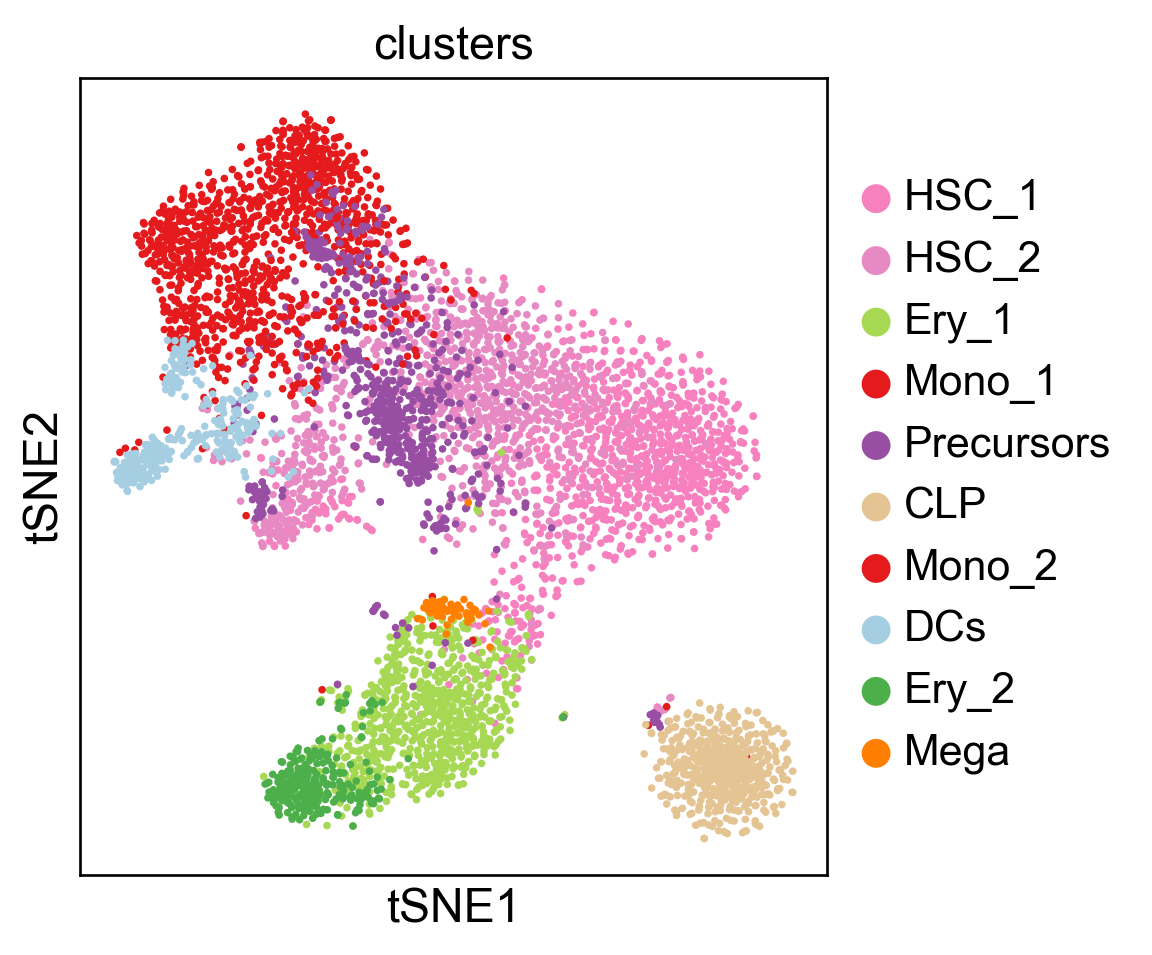

In [19]:

sc.pl.scatter(adata, basis="tsne", color="clusters")

In [20]:
sc.tl.diffmap(adata, n_comps=10)
X_diffmap = adata.obsm["X_diffmap"]

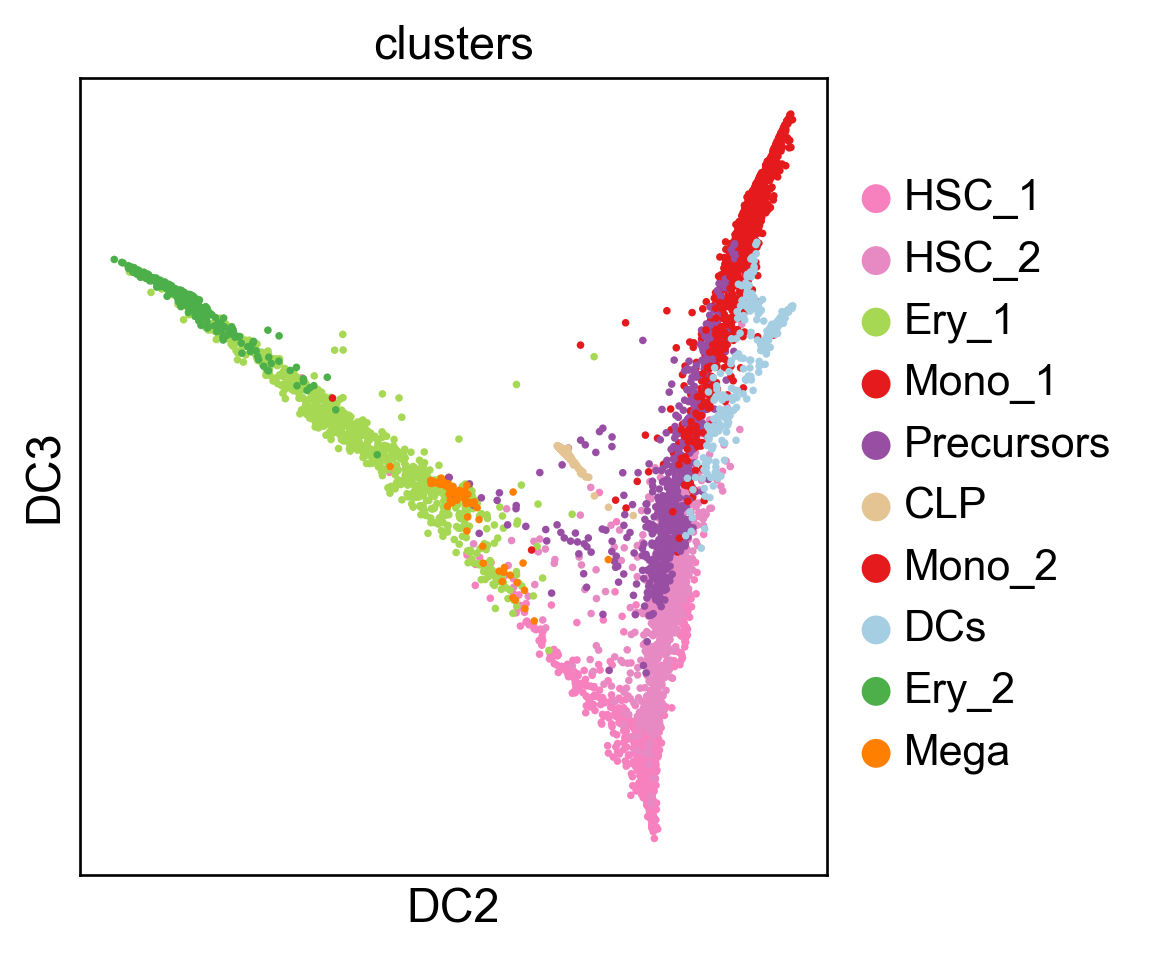

In [21]:
sc.pl.scatter(
    adata,
    basis="diffmap",
    color=["clusters"],
    components=[2, 3],
)

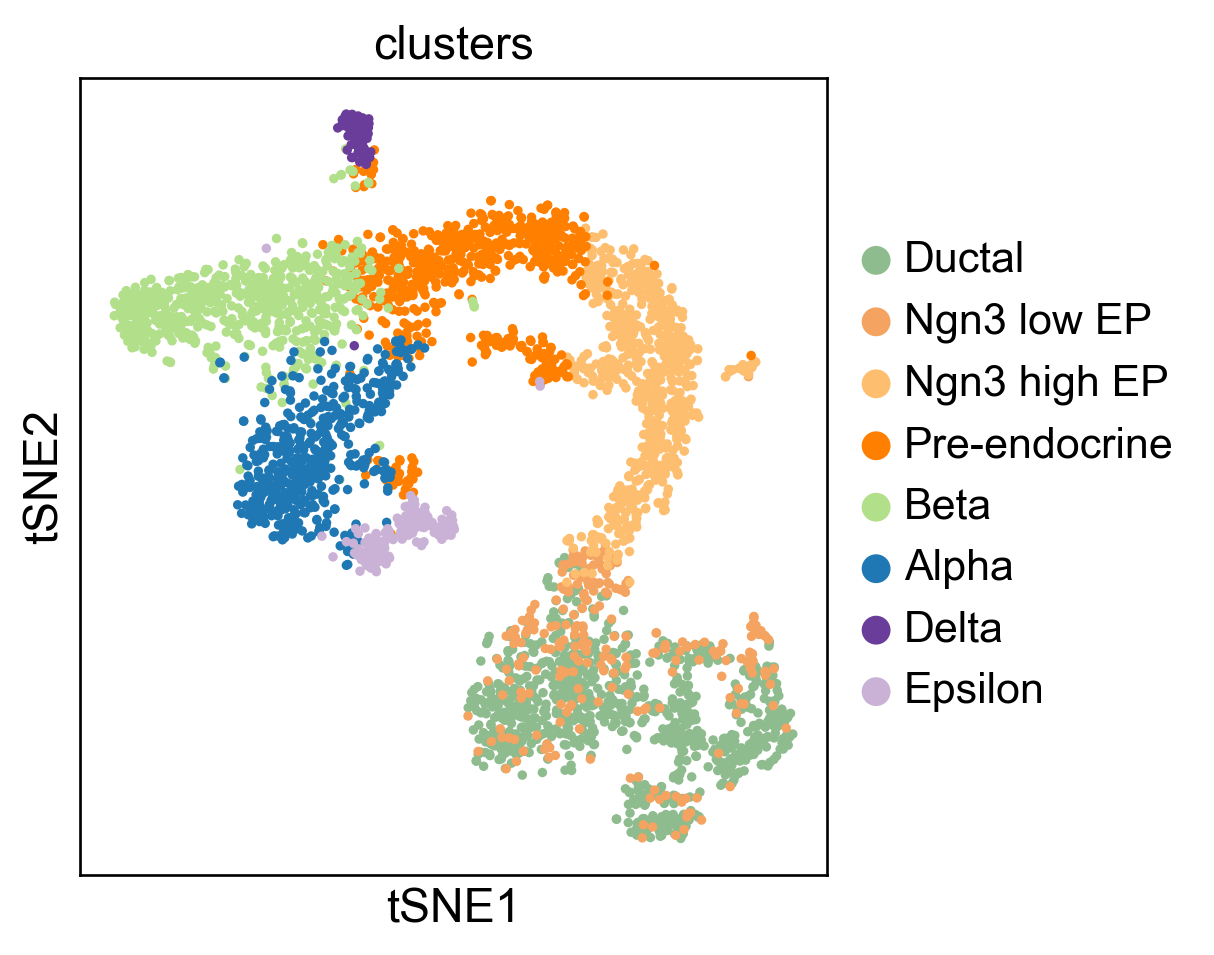

In [98]:
# Setting root cell as described above
root_ixs = adata.obsm["X_tsne"][:, 1].argmin()
sc.pl.scatter(
    adata,
    basis="tsne",
    color=["clusters"],
    )

adata.uns["iroot"] = root_ixs


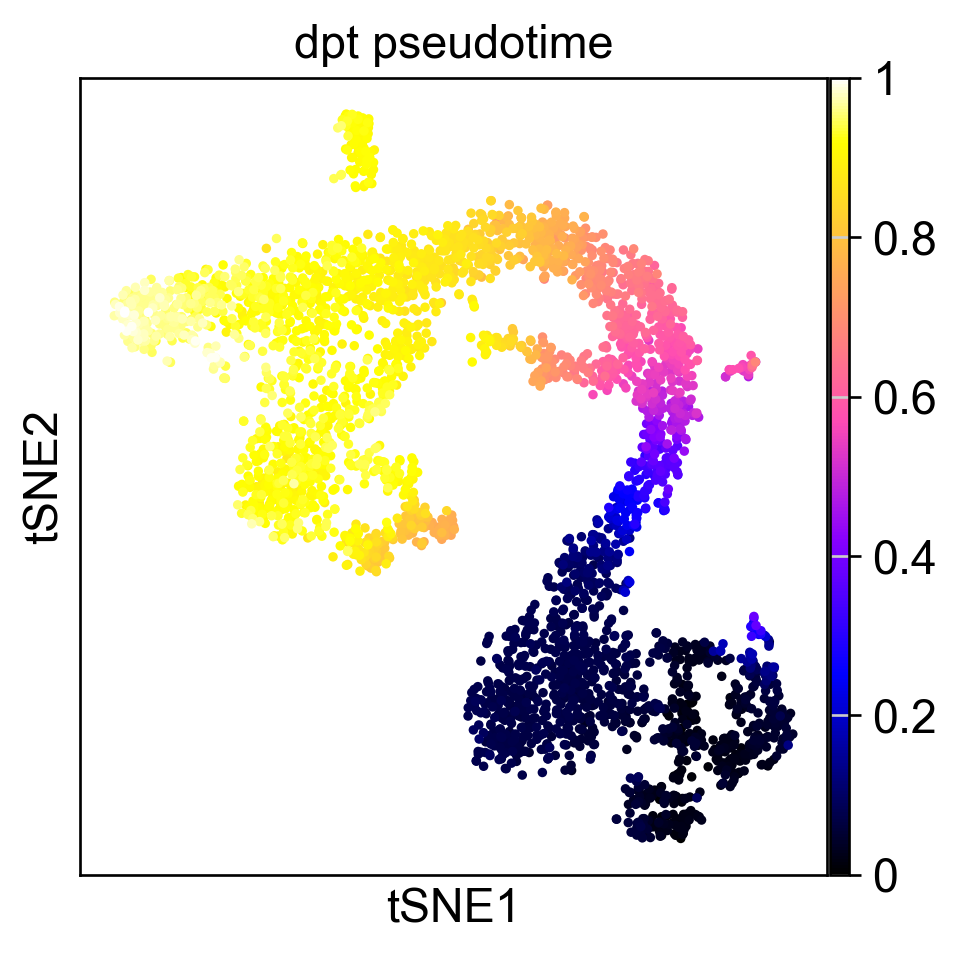

In [99]:
sc.tl.dpt(adata)
sc.pl.scatter(
    adata,
    basis="tsne",
    color=["dpt_pseudotime"],
    color_map="gnuplot2",
)

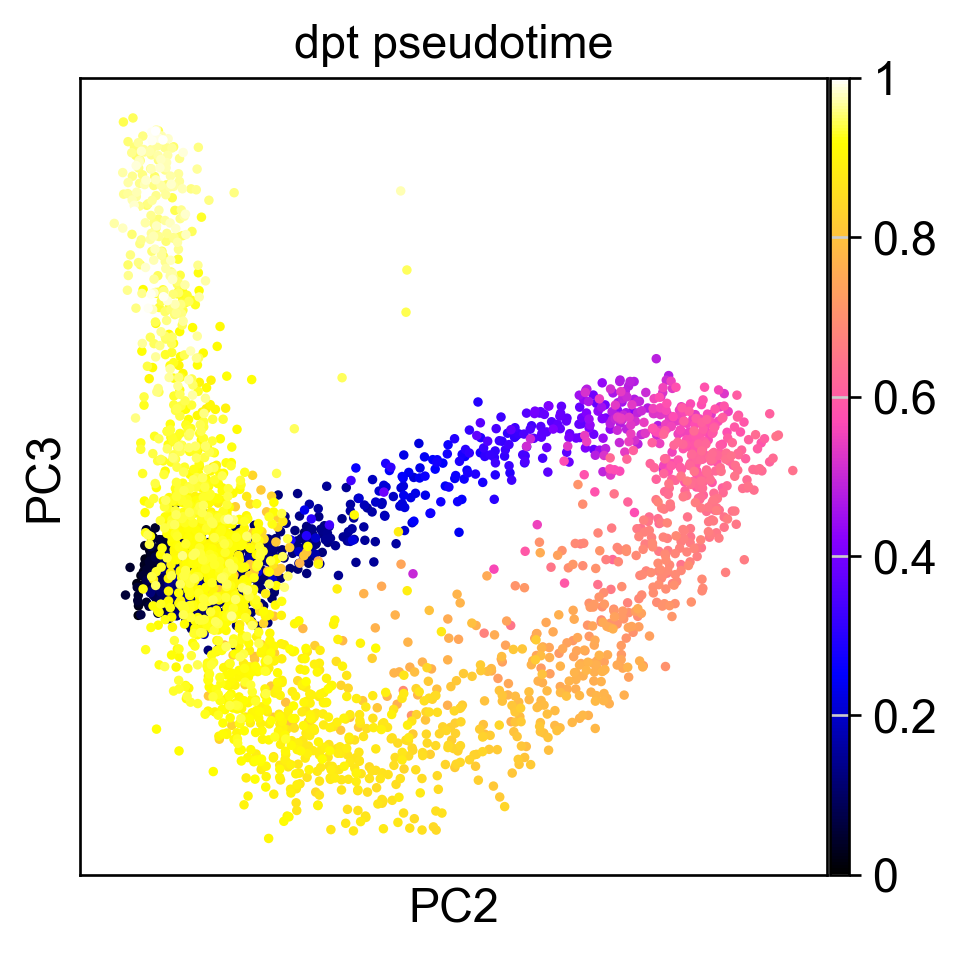

In [83]:
sc.pl.scatter(
    adata,
    basis="pca",
    components=[2,3],
    color=["dpt_pseudotime"],
    color_map="gnuplot2",)

In [ ]:
import torch
import scipy
import numpy as np
X = torch.FloatTensor(adata.X.toarray() if scipy.sparse.issparse(adata.X) else adata.X)

In [ ]:
from sklearn.neighbors import NearestNeighbors
import torch_geometric.utils as pyg_utils

# Compute directed nearest neighbors
n_neighbors = 15  # Default k value
nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(X)
distances, indices = nbrs.kneighbors(X)

# Create directed connectivity matrix
n_cells = adata.n_obs
rows = np.repeat(np.arange(n_cells), n_neighbors)
cols = indices.flatten()
data = np.ones_like(cols)

# Remove self-loops
mask = rows != cols
rows = rows[mask]
cols = cols[mask]
data = data[mask]

# Create directed connectivity matrix without self-loops
adata.obsp['directed_connectivities'] = scipy.sparse.csr_matrix(
    (data, (rows, cols)), shape=(n_cells, n_cells)
)

# By default use the directed graph
adata.obsp['connectivities'] = adata.obsp['directed_connectivities'].copy()
# scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

# Prepare input features (x) and adjacency matrix (adj) for DiffPool
# Extract the original features as node features
x = torch.tensor(adata.X.toarray(), dtype=torch.float)

# Extract the adjacency matrix
adj = pyg_utils.to_dense_adj(
    pyg_utils.from_scipy_sparse_matrix(adata.obsp['connectivities'])[0]
).squeeze(0)

# Ensure the adjacency matrix is symmetric
# adj = (adj + adj.transpose(0, 1)) / 2

# Convert adjacency matrix to float
adj = adj.to(torch.float)

In [ ]:
from main3 import setup_experiment, setup_model

run_id, run_dir, logger = setup_experiment()
# Setup model, vector field and optimizer
model, vf, optimizer, c = setup_model(x, adj, logger)



2026-01-07 18:30:03,387 [INFO] Starting training run 20260107_183003


In [ ]:
def OT_graph_similarity(X_diffmap, node_embeddings):
    """
    Numerically stable Sinkhorn alignment loss between coarsened nodes
    and target cluster centers.

    Parameters
    ----------
    x_diffmap : torch.Tensor [N, d]
        Diffusion Dimensionality Reduction
    node_embeddings : torch.Tensor [N, d]
        Original node embeddings after coarsening 


    Returns
    -------
    loss : torch.Tensor (scalar)
        Differentiable alignment loss
   
    """

    N = X_diffmap.shape[0]
    n = node_embeddings.shape[0]
    # 1. Compute pairwise squared distances (cost matrix)
    C = torch.cdist(node_embeddings, torch.tensor(X_diffmap, dtype=torch.float32), p=2) ** 2
    # 2. Compute alignment loss
    D = torch.diag(np.ones(N))
    
    return torch.sum(D*C) / (N*n)

In [ ]:
def train_model(model, vf, optimizer, x, adj, adata_subsampled, epochs, run_dir, logger):
    """Core training loop"""
    log_interval = 10
    
    # Enable anomaly detection
    torch.autograd.set_detect_anomaly(True)
    
    # Tracking metrics
    losses = []
    grad_norms_vf = []
    grad_norms_model = []
    x_sums = []
    

    # Training loop
    for i in range(epochs):
        # Clear all gradients
        optimizer.zero_grad()
        
        # Forward pass through DiffPool model
        x_out, adj_out = model(x, adj)
        

        #Abhi
        node_embeddings = model.compute_node_embeddings(x, adj, full_hierarchy=True)

        L_emb = OT_graph_similarity(X_diffmap, node_embeddings) 

        L = L_emb
        print(L)
        # Compute gradients
        L.backward()
        
        # Update parameters
        optimizer.step()
        
        # Store metrics
        losses.append(L.item())

    return losses, node_embeddings

In [ ]:
epochs = 10
losses, node_embeddings = train_model(model, vf, optimizer, x, adj, adata, epochs, run_dir, logger)
